예제 8.4 DCGAN(파이토치)

In [ ]:
# 예제 8.4 DCGAN CelebA(파이토치)

# 셋업
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data
from torch.utils.data.dataloader import DataLoader
from torchvision.transforms import Compose, ToTensor, Normalize
from torchvision.transforms import Resize, CenterCrop
import torchvision.datasets as dset
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
from IPython import display

# 디바이스 지정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# 데이터셋 준비/전처리
dir_path = "/content/celeba"

transform=Compose([Resize(64),
                   CenterCrop(64),
                   ToTensor(),
                   Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

dataset = dset.ImageFolder(root=dir_path, transform=transform)

print(len(dataset))   # 데이터셋 크기 확인

202599


In [ ]:
# 학습 데이터 로더 생성
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

print(len(train_loader))   # 학습 데이터 로더 크기 확인

6332


In [ ]:
# 소규모 CelebA 데이터셋
# sub_dataset = torch.utils.data.Subset(dataset, range(10000))   # 10,000개 샘플
# train_loader = DataLoader(sub_dataset, batch_size=32, shuffle=True)

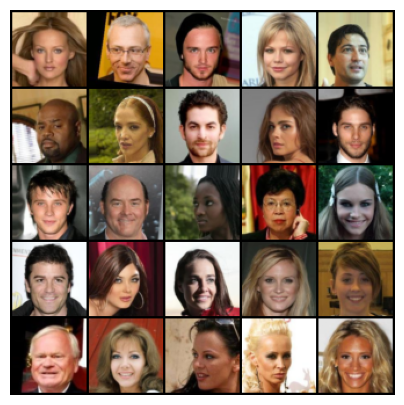

In [ ]:
# 학습 이미지 시각화
train_images = next(iter(train_loader))   # 반복 객체로 변환, 다음 배치 가져옴

plt.figure(figsize=(5, 5))

plt.imshow(np.transpose(vutils.make_grid(
    train_images[0].to(device)[:25],
    padding=2,                   # 이미지 간격 2 픽셀
    normalize=True,              # 정규화
    nrow=5).cpu(), (1 ,2, 0)))   # 5x5 그리드/(H, W, C) 변환
plt.axis("off")

plt.show()

In [ ]:
# 생성자 정의
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.gen = nn.Sequential(
            nn.ConvTranspose2d(100, 512, kernel_size=4, stride=1,
                               padding=0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2,
                               padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2,
                               padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2,
                               padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2,
                               padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, inputs):
        return self.gen(inputs)

generator = Generator().to(device)

# 생성자 구조 확인
generator

Generator(
  (gen): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)

In [ ]:
# 생성자 구조 요약
# !pip install torchsummary(코랩에서는 설치할 필요가 없음)
from torchsummary import summary

summary(generator, input_size=(100, 1, 1))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
   ConvTranspose2d-1            [-1, 512, 4, 4]         819,200
       BatchNorm2d-2            [-1, 512, 4, 4]           1,024
              ReLU-3            [-1, 512, 4, 4]               0
   ConvTranspose2d-4            [-1, 256, 8, 8]       2,097,152
       BatchNorm2d-5            [-1, 256, 8, 8]             512
              ReLU-6            [-1, 256, 8, 8]               0
   ConvTranspose2d-7          [-1, 128, 16, 16]         524,288
       BatchNorm2d-8          [-1, 128, 16, 16]             256
              ReLU-9          [-1, 128, 16, 16]               0
  ConvTranspose2d-10           [-1, 64, 32, 32]         131,072
      BatchNorm2d-11           [-1, 64, 32, 32]             128
             ReLU-12           [-1, 64, 32, 32]               0
  ConvTranspose2d-13            [-1, 3, 64, 64]           3,072
             Tanh-14            [-1, 3,

In [ ]:
# 판별자 정의
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.disc = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2,
                      padding=1, bias=False),
            nn.LeakyReLU(negative_slope=0.2),

            nn.Conv2d(64, 128, kernel_size=4, stride=2,
                      padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(negative_slope=0.2),

            nn.Conv2d(128, 256, kernel_size=4, stride=2,
                      padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(negative_slope=0.2),

            nn.Conv2d(256, 512, kernel_size=4, stride=2,
                      padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(negative_slope=0.2),

            nn.Conv2d(512, 1, kernel_size=4, stride=1,
                      padding=0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, inputs):
        return self.disc(inputs)

discriminator = Discriminator().to(device)

# 판별자 구조 확인
discriminator

Discriminator(
  (disc): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)

In [ ]:
# 판별자 구조 요약
summary(discriminator, input_size=(3, 64, 64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           3,072
         LeakyReLU-2           [-1, 64, 32, 32]               0
            Conv2d-3          [-1, 128, 16, 16]         131,072
       BatchNorm2d-4          [-1, 128, 16, 16]             256
         LeakyReLU-5          [-1, 128, 16, 16]               0
            Conv2d-6            [-1, 256, 8, 8]         524,288
       BatchNorm2d-7            [-1, 256, 8, 8]             512
         LeakyReLU-8            [-1, 256, 8, 8]               0
            Conv2d-9            [-1, 512, 4, 4]       2,097,152
      BatchNorm2d-10            [-1, 512, 4, 4]           1,024
        LeakyReLU-11            [-1, 512, 4, 4]               0
           Conv2d-12              [-1, 1, 1, 1]           8,192
          Sigmoid-13              [-1, 1, 1, 1]               0
Total params: 2,765,568
Trainable param

In [ ]:
# 에포크 별 생성 이미지 확인 함수 정의
def display_image(epoch_no):
    generated_image = img_list[epoch_no - 1]

    plt.figure(figsize=(10, 5))

    plt.imshow(np.transpose(generated_image, (1, 2, 0)))   # (H, W, C) 변환
    plt.title(f"Generated Images at Epoch {epoch_no}")
    plt.axis("off")

    plt.show()

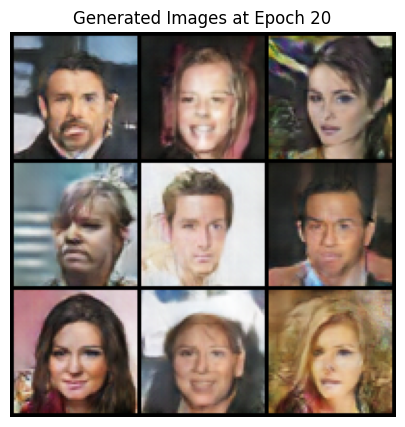

In [ ]:
# 학습
epochs = 20        # 반복 횟수
latent_dim = 100   # 랜덤 벡터 차원
num_generate = 9   # 생성할 이미지 수
seed = torch.randn(num_generate, latent_dim, 1, 1,  # 생성자 학습 시작 입력
                   device=device)

# 손실 함수 설정
loss_fn = nn.BCELoss()

# 옵티마이저 설정
g_optimizer = optim.Adam(generator.parameters(),
                         lr=0.0002, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(),
                         lr=0.0002, betas=(0.5, 0.999))

img_list = []   # 생성된 이미지 리스트
for epoch in range(epochs):
    for i, data in enumerate(train_loader, 0):

        # 판별자 학습
        discriminator.zero_grad()   # 그레디언트 초기화

        label_real = torch.ones_like(data[1], dtype=torch.float32).to(device)
        label_fake = torch.zeros_like(data[1], dtype=torch.float32).to(device)

        real_output = discriminator(data[0].to(device)).view(-1)
        real_loss = loss_fn(real_output, label_real)
        real_loss.backward()   # 역전파

        noise = torch.randn(label_fake.shape[0], latent_dim, 1, 1, device=device)
        fake_images = generator(noise)
        fake_output = discriminator(fake_images.detach()).view(-1)
        fake_loss = loss_fn(fake_output, label_fake)
        fake_loss.backward()   # 역전파

        d_loss = real_loss + fake_loss   # 판별자 전체 손실
        d_optimizer.step()   # 최적화 수행

        # 생성자 학습
        generator.zero_grad()   # 그레디언트 초기화

        fake_output = discriminator(fake_images).view(-1)
        g_loss = loss_fn(fake_output, label_real)   # 생성자 손실 계산
        g_loss.backward()    # 역전파

        g_optimizer.step()   # 최적화 수행

    # 생성된 이미지 저장
    with torch.no_grad():
        generated_images = generator(seed).detach().cpu()
    img_list.append(vutils.make_grid(generated_images, padding=2,
                                     normalize=True, nrow=3))

    # 에포크마다 이미지 출력
    display.clear_output(wait=True)
    display_image(epoch_no=epoch+1)

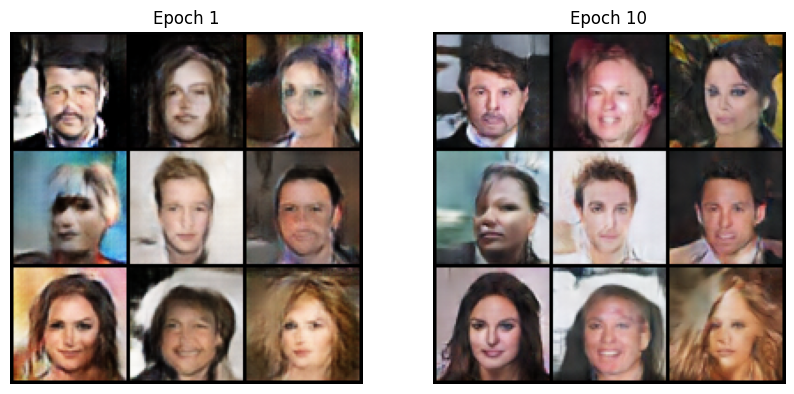

In [ ]:
# 에포크 별 생성 이미지 확인
fig, axs = plt.subplots(1, 2, figsize=(10, 10))

ax = axs[0]
ax.imshow(np.transpose(img_list[0], (1, 2, 0)))   # (H, W, C) 변환
ax.set_title(f"Epoch 1")
ax.axis("off")

ax = axs[1]
ax.imshow(np.transpose(img_list[9], (1, 2, 0)))
ax.set_title(f"Epoch 10")
ax.axis("off")

plt.show()

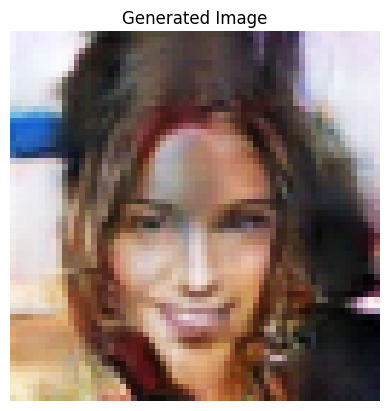

In [ ]:
# 생성 이미지 확인
torch.manual_seed(3)

with torch.no_grad():
    noise = torch.randn(1, 100, 1, 1).to(device)
    generated_image = generator(noise).squeeze()
    generated_image = generated_image.permute(1, 2, 0).cpu().numpy()
    generated_image = (generated_image - generated_image.min()) /\
       (generated_image.max() - generated_image.min())   # 픽셀 값(0 ~ 1)

plt.imshow(generated_image)
plt.title('Generated Image')
plt.axis('off'
plt.show()

In [ ]:
# 모델 저장
torch.save(generator.state_dict(),
           '/content/drive/MyDrive/Colab Notebooks/models/celeba_gan.pth')

In [ ]:
# 모델 불러오기
generator.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks/models/celeba_gan.pth')